# Skill Lab 1 | Análisis y selección de modelos para un caso de negocio
**Individual · 5 puntos · Entrega de resultados en PDF · 1.6 horas · Modo precargado: sin API y sin costo**

## Contexto de negocio

Distribuidora Cuauhtémoc es una empresa de consumo masivo con marcas de alimentos y cuidado personal. Vende por cuatro canales; el más grande es el canal tradicional: decenas de miles de tiendas atendidas por **preventistas** que visitan, levantan pedido y reportan lo que ven en el anaquel.

La dirección aprobó explorar un asistente agéntico de inteligencia comercial, y las dos primeras necesidades sobre la mesa son tareas con **perfiles opuestos**:

| Tarea | Quién la usa | Cuándo | Qué exige |
|---|---|---|---|
| **Consulta de campo** | El preventista frente a la tienda | En vivo, cientos de veces al día | Respuesta en segundos, costo bajo por llamada, errores tolerables (el humano está ahí) |
| **Resumen nocturno de incidentes** | El gerente comercial | Una corrida por noche, en lote | Máxima calidad de síntesis; la latencia no importa; un error llega al comité sin filtro |

**Tu papel en este laboratorio:** eres el analista que recomienda qué modelo usar en cada tarea. No con intuición ni con la demo más reciente: con datos didácticos, un criterio definido antes de consultar la comparación, y una decisión documentada que un tercero pueda auditar.

## Objetivo

Al terminar este laboratorio habrás:

1. **Analizado conteos de tokens y calculado costos** con datos didácticos del caso, entendiendo por qué el token es la unidad de cobro y de capacidad.
2. **Observado el efecto de posición** (por qué la evidencia enterrada a media ventana rinde menos) y derivado su implicación de diseño.
3. **Analizado una comparación precargada con criterio previo**: la disciplina metodológica que separa una evaluación de una justificación.
4. **Documentado tu decisión** en una *Model Decision Card* verificable, el artefacto que tu equipo reutilizará en el proyecto.

## Diccionario de datos del laboratorio

Trabajas con **datos didácticos precargados**, tratados aquí como una simulación. El paquete no incluye textos fuente, salidas individuales ni una bitácora que permita verificar mediciones de modelos reales. No ejecuta inferencias ni llama a una API. Sí calcularás costos y métricas derivadas a partir de los valores del conjunto común, y explicarás qué permiten concluir y qué no.

El archivo `skill_lab1_variants.json` contiene el conjunto común del laboratorio, seleccionado automáticamente:

| Campo | Qué es |
|---|---|
| `texto_tokens.consulta_campo` | Tokens de una consulta típica de preventista |
| `texto_tokens.reporte_incidentes` | Tokens del reporte diario de incidentes |
| `texto_tokens.catalogo` | Tokens del catálogo completo de productos |
| `ratio_es_en` | Razón didáctica de conteos español/inglés; no es una medición realizada por este notebook |
| `pos_score.{inicio,medio,final}` | Puntuación (0-1) de la misma pregunta con la evidencia colocada en cada posición de un contexto largo |
| `eval_20.{rapido,capaz}` | Resultados agregados simulados para 20 casos y dos modelos: `aciertos`, `costo_total` (USD), `latencia_media` (s) |

Todos trabajaremos con los mismos datos. La interpretación y las recomendaciones son individuales.

## Cómo trabajar este notebook

- Ejecuta las celdas **en orden**: cada sección explica el concepto, muestra la técnica y te pide una decisión.
- Las celdas marcadas **DECISIÓN** son tuyas; las que traen `_____` deben completarse antes de continuar (el notebook te avisa).
- La regla más importante llega en la sección C: el criterio de aceptación se escribe **antes** de ver resultados. La función de comparación comprueba que registraste un criterio y que no cambió después. Es un control local de trabajo, no un preregistro inalterable: el archivo de datos y el código siguen siendo accesibles.
- Al final, la celda-resumen reúne tus resultados y detecta campos pendientes. Entrega un PDF con resultados, interpretación, ambas cards, conclusiones y declaración de IA. El profesor lo revisa conforme a la rúbrica de Canvas: 3 puntos de resultados y 2 de interpretación. El notebook es tu material de trabajo; no hay quiz de captura ni una segunda entrega.
- Puedes usar IA como apoyo conforme a la política del curso; tu declaración de uso va en la sección D.

**Preparación en Colab:** descarga y descomprime el ZIP de Canvas. Abre el archivo `.ipynb` con la opción de subir notebook de Colab. En el panel de archivos de esa sesión, sube `skill_lab1_variants.json` y después ejecuta las celdas en orden. Si Colab reinicia o elimina la sesión, vuelve a subir el JSON. No necesitas los CSV del proyecto Construye ni una clave de API para este laboratorio.


### El mapa del laboratorio

```
  SECCIÓN A            SECCIÓN B             SECCIÓN C              SECCIÓN D
  Tokens y costo  -->  Efecto de        -->  Evaluación con    -->  Model Decision
  ¿qué cuesta          posición              criterio previo        Card
   cada texto?         ¿dónde rinde          ¿qué modelo            la decisión,
                        la evidencia?         acierta más?           documentada
       \____________________ evidencia acumulada ____________________/
                                    |
                                    v
                     Celda-resumen  -->  entrega en Canvas
```

Cada sección produce evidencia que la siguiente usa; la card final se sostiene sobre las tres anteriores. Por eso el orden importa.

# Librerías

Tres librerías, cada una con un porqué:

- **pandas** — toda evidencia de este lab vive en tablas; compararás modelos con DataFrames, no con prints sueltos. Es el estándar del análisis de datos en Python.
- **matplotlib** — vas a *ver* los patrones (costo, posición, trade-offs) antes de decidir. Una decisión de modelo sin gráfica es una decisión sin conversación.
- **Tokenización** — la demostración incluye una estimación aproximada y admite un codificador ya cargado en el entorno. Distingue ese ejemplo de los conteos didácticos del conjunto común. El notebook no instala paquetes ni descarga codificadores.

In [1]:
# No se instalan dependencias desde este notebook.
# Usa el entorno del curso con pandas y matplotlib disponibles.
# Si falta alguna, consulta al equipo docente antes de modificar tu entorno.

In [2]:
import json
import os
import re
import math
import hashlib
import pandas as pd
import matplotlib.pyplot as plt

# Opcional: el docente puede proporcionar un codificador ya cargado en memoria.
# No invocar aquí descargas ni get_encoding; None activa la estimación didáctica.
ENCODIFICADOR_LOCAL = None

def texto_completo(valor):
    return (isinstance(valor, str) and bool(valor.strip())
            and not re.search(r"_{3,}", valor)
            and valor.strip().casefold() not in {"pendiente", "por completar", "por confirmar", "n/a"}
            and any(c.isalpha() for c in valor))

def firma_variante():
    contenido = json.dumps([CODIGO_LAB, v], sort_keys=True, allow_nan=False)
    return hashlib.sha256(contenido.encode('utf-8')).hexdigest()

registro_criterio = None

def registrar_criterio(criterio):
    global registro_criterio
    registro_criterio = None
    if not texto_completo(criterio):
        raise ValueError('Escribe un criterio de aceptación, sin dejar el marcador vacío.')
    registro_criterio = {'criterio': criterio.strip(), 'variante': firma_variante()}

def comprobar_criterio():
    if not texto_completo(CRITERIO_ACEPTACION) or registro_criterio is None:
        raise ValueError('Primero completa y ejecuta la celda de registro del criterio (C).')
    if (registro_criterio['criterio'] != CRITERIO_ACEPTACION.strip()
            or registro_criterio['variante'] != firma_variante()):
        raise ValueError('Cambió el criterio o la variante. Revisa y vuelve a ejecutar desde el registro; documenta la revisión.')

pd.set_option('display.precision', 2)
print(f'pandas {pd.__version__} | modo precargado, sin instalaciones ni llamadas a modelos')

pandas 2.3.3 | modo precargado, sin instalaciones ni llamadas a modelos


# Carga del conjunto común

Todos trabajaremos con los mismos datos. No necesitas recibir ni ingresar un código. Conserva la configuración inicial de la siguiente celda: `LAB1-A` es un identificador interno, no una asignación por alumno.


In [3]:
# Configuración común del laboratorio: no cambies este valor
CODIGO_LAB = "LAB1-A"   # conjunto común para todos

assert os.path.exists("skill_lab1_variants.json"), (
    "No encuentro skill_lab1_variants.json. Descarga el zip de Canvas y "
    "coloca el archivo JUNTO a este notebook (en Colab: arrástralo al panel de archivos).")

with open("skill_lab1_variants.json", encoding="utf-8") as archivo:
    V = json.load(archivo)
if CODIGO_LAB not in V:
    raise SystemExit(f"No se encontró el conjunto común del laboratorio. "
                     "Conserva CODIGO_LAB = LAB1-A y vuelve a cargar el archivo JSON incluido en el ZIP.")
v = V[CODIGO_LAB]

registro_criterio = None
print(f"Conjunto común cargado. Datos de las secciones A y B:")
display(pd.json_normalize({k: v[k] for k in ("texto_tokens", "ratio_es_en", "pos_score")}, sep=" · ").T.rename(columns={0: "valor"}))
print("La comparación de modelos se muestra en C, después del registro del criterio.")

Conjunto común cargado. Datos de las secciones A y B:


,valor
ratio_es_en,1.32
texto_tokens · consulta_campo,47.00
texto_tokens · reporte_incidentes,449.00
texto_tokens · catalogo,1580.00
pos_score · inicio,0.86
pos_score · medio,0.71
pos_score · final,0.88


La comparación de modelos se muestra en C, después del registro del criterio.


## Sección A — Tokens y costo

### El concepto

Un modelo de lenguaje no lee palabras: lee **tokens**, fragmentos de texto producidos por un algoritmo de segmentación (BPE, *byte-pair encoding*). El token es la unidad en la que se mide TODO lo que le importa a tu caso de negocio:

- **El costo**: los proveedores cobran por token de entrada y de salida.
- **La capacidad**: la ventana de contexto es un presupuesto de tokens; lo que no cabe, no existe para el modelo.
- **El idioma**: los tokenizadores se entrenaron mayormente en inglés, así que el mismo contenido en español suele costar más tokens. Esa razón (`ratio_es_en`) es un dato de presupuesto, no una curiosidad.

```
  "El preventista reporta quiebre…"      ← texto (lo que TÚ ves)
          |
          |  tokenizador (BPE)
          v
  ["El", " prevent", "ista", " rep…"]    ← tokens (lo que el MODELO ve y el proveedor COBRA)
          |
          |  × tarifa por token
          v
   $ por llamada  →  × llamadas/día  →  $ de operación al día
```

### La técnica: distinguir un conteo de una estimación

La siguiente celda ilustra el conteo con dos frases. Si el entorno no aporta un codificador ya cargado, usa una aproximación de cuatro caracteres por token, que puede diferir mucho de una tokenización real. No sirve para comprobar costos de un proveedor ni diferencias entre idiomas. Los cálculos posteriores usan los conteos didácticos del conjunto común, no esta aproximación.

In [4]:
def contar_tokens(texto: str) -> int:
    """Cuenta con el codificador proporcionado o estima; no descarga recursos."""
    if not isinstance(texto, str):
        raise TypeError('El texto debe ser una cadena.')
    if not texto:
        return 0
    if ENCODIFICADOR_LOCAL is not None:
        return len(ENCODIFICADOR_LOCAL.encode(texto))
    return max(1, round(len(texto) / 4))

frase_es = "El preventista reporta quiebre de inventario del producto P047 en la tienda T0231."
frase_en = "The field rep reports a stockout of product P047 at store T0231."
modo = 'conteo con codificador local' if ENCODIFICADOR_LOCAL is not None else 'ESTIMACIÓN aproximada, no tokenización real'
print(modo)
print(f'es={contar_tokens(frase_es)} | en={contar_tokens(frase_en)}')
print(f"Razón didáctica español/inglés de la variante: x{v['ratio_es_en']}")

ESTIMACIÓN aproximada, no tokenización real
es=20 | en=16
Razón didáctica español/inglés de la variante: x1.32


### Los tres textos del caso: conteos didácticos

El conjunto común incluye conteos didácticos de tres textos que el asistente podría necesitar. La pregunta de diseño: **¿cuáles pueden entrar completos a la mesa en cada llamada, y cuál no?**

Para dimensionar el costo usamos **tarifas de referencia didácticas** (dólares por millón de tokens de entrada): no son una cotización vigente. El ejercicio calcula solo entrada; una estimación de operación real también debe contemplar salida, volumen y condiciones del proveedor.

In [5]:
TARIFA_ENTRADA = {"rapido": 0.15, "capaz": 1.25}   # USD por millón de tokens (referencia didáctica)
LLAMADAS_DIA = 1000                                 # consultas de campo estimadas por día

tokens = pd.Series(v["texto_tokens"], name="tokens")
df_a = tokens.to_frame()
for modelo, tarifa in TARIFA_ENTRADA.items():
    df_a[f"USD/llamada ({modelo})"] = tokens * tarifa / 1_000_000
    df_a[f"USD/día x{LLAMADAS_DIA} ({modelo})"] = df_a[f"USD/llamada ({modelo})"] * LLAMADAS_DIA
display(df_a)

caro = tokens.idxmax()
print(f"Si metieras '{caro}' completo en CADA llamada de campo, solo ese texto costaría "
      f"{df_a.loc[caro, f'USD/día x{LLAMADAS_DIA} (capaz)']:.2f} USD/día con el modelo capaz — antes de contar la salida.")

,tokens,USD/llamada (rapido),USD/día x1000 (rapido),USD/llamada (capaz),USD/día x1000 (capaz)
consulta_campo,47,7.05e-06,7.05e-03,5.87e-05,0.06
reporte_incidentes,449,6.73e-05,6.73e-02,5.61e-04,0.56
catalogo,1580,2.37e-04,2.37e-01,1.98e-03,1.98


Si metieras 'catalogo' completo en CADA llamada de campo, solo ese texto costaría 1.98 USD/día con el modelo capaz — antes de contar la salida.


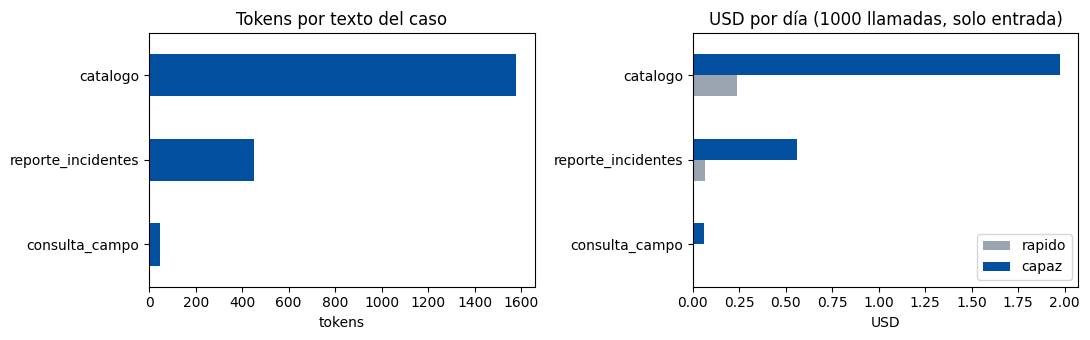

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
tokens.plot.barh(ax=ax[0], color="#0350a1")
ax[0].set_title("Tokens por texto del caso"); ax[0].set_xlabel("tokens")
(df_a[[c for c in df_a.columns if "USD/día" in c]]
 .rename(columns=lambda c: c.split("(")[1].rstrip(")"))
 .plot.barh(ax=ax[1], color=["#9aa5b1", "#0350a1"]))
ax[1].set_title(f"USD por día ({LLAMADAS_DIA} llamadas, solo entrada)"); ax[1].set_xlabel("USD")
plt.tight_layout(); plt.show()

**Qué deberías ver:** una tabla con los tres textos y su costo por llamada y por día para cada modelo, y dos gráficas de barras. El contraste importante: la consulta de campo cuesta centavos al día; el catálogo completo, dólares — y eso es SOLO la entrada de un texto.

### El método: la decisión de mesa

La regla del curso (la verás formalizada en la lección de contexto): **a la mesa entra la evidencia decisiva, no el archivero completo**. Con tus números enfrente, responde:

In [7]:
# DECISIÓN | Completa con el nombre del texto: consulta_campo, reporte_incidentes o catalogo
TEXTO_QUE_NO_ENTRA_COMPLETO = "catalogo"
POR_QUE = """El catálogo pesa 1580 tokens, 33.6 veces la consulta de campo (47 tokens): completo en cada una de las 1000 llamadas diarias costaría 1.975 USD/día solo de entrada con el capaz (0.237 USD/día con el rápido), contra 0.059 y 0.007 USD/día de la consulta.
Además, de esos 1580 tokens el preventista solo necesita los pocos renglones del SKU y la tienda que consulta; el resto es ruido que encarece cada llamada y empuja la evidencia útil hacia el medio de la ventana (sección B), así que se recuperan solo los renglones pertinentes."""

if not texto_completo(TEXTO_QUE_NO_ENTRA_COMPLETO) or not texto_completo(POR_QUE):
    print("Completa TEXTO_QUE_NO_ENTRA_COMPLETO y POR_QUE antes de seguir: incluye esta interpretación en tu PDF de resultados.")
else:
    ok = TEXTO_QUE_NO_ENTRA_COMPLETO in v["texto_tokens"]
    print("Registrado." if ok else f"'{TEXTO_QUE_NO_ENTRA_COMPLETO}' no es un texto del caso; revisa la tabla de la sección A.")

Registrado.


## Sección B — El efecto de posición

### El concepto

Que un dato *quepa* en la ventana no significa que *pese* lo mismo en cualquier posición. La investigación lo documentó con precisión (Liu et al., 2023, *Lost in the Middle*): los modelos usan mejor la evidencia colocada **al inicio o al final** de un contexto largo, y peor la que queda **enterrada en medio**.

El conjunto común ilustra este efecto con puntuaciones didácticas de 0 a 1 para tres posiciones. No se ejecuta aquí el experimento ni se acredita un resultado de un modelo particular. Usa la gráfica para interpretar el patrón y sus límites.

```
  VENTANA DE CONTEXTO = un presupuesto de tokens
  +--------------------------------------------------+
  |  INICIO           MEDIO              FINAL       |
  |  █████ rinde      ▒▒▒▒▒ rinde       █████ rinde  |
  |  ALTO             BAJO               ALTO        |
  +--------------------------------------------------+
        la MISMA evidencia rinde distinto según DÓNDE quede
        (Liu et al., 2023: "lost in the middle")
```

,inicio,medio,final
score,0.86,0.71,0.88


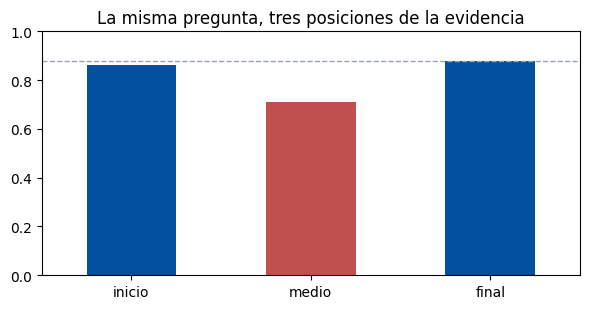

Enterrar la evidencia a media ventana cuesta 19% de desempeño en tu variante — sin cambiar de modelo ni pagar un token más.


In [8]:
pos = pd.Series(v["pos_score"], name="score")[["inicio", "medio", "final"]]
display(pos.to_frame().T)

fig, ax = plt.subplots(figsize=(6, 3.2))
colores = ["#0350a1" if p != pos.idxmin() else "#c0504d" for p in pos.index]
pos.plot.bar(ax=ax, color=colores, rot=0)
ax.axhline(pos.max(), ls="--", lw=1, color="#9aa5b1")
ax.set_ylim(0, 1); ax.set_title("La misma pregunta, tres posiciones de la evidencia")
plt.tight_layout(); plt.show()

caida = (pos.max() - pos["medio"]) / pos.max() * 100
print(f"Enterrar la evidencia a media ventana cuesta {caida:.0f}% de desempeño en tu variante — sin cambiar de modelo ni pagar un token más.")

**Qué deberías ver:** tres barras con el `medio` en rojo (el más bajo) y una línea punteada en el máximo. El mensaje de abajo te dice qué porcentaje relativo del valor máximo cuesta enterrar la evidencia — gratis, sin cambiar de modelo.

### Interpretación guiada

Tres implicaciones de diseño, de la más obvia a la más cara de ignorar:

1. **El orden del paquete de contexto es una decisión de ingeniería**, no un accidente: la evidencia decisiva va al inicio o al final.
2. **Más contexto puede rendir menos**: cada fragmento irrelevante que agregas empuja al resto hacia el medio. (Conecta con tu respuesta de la sección A.)
3. **Esto se mide, no se supone**: este ejemplo no sustituye una medición sobre el sistema que se quiera evaluar. Para verificar el efecto se necesitan casos, salidas y condiciones de prueba documentadas.

*Incluye en tu interpretación: ¿qué implica el efecto de posición para el diseño del paquete de contexto del agente?*

## Sección C — Evaluación comparativa con criterio previo

### El método (la parte más importante del laboratorio)

Vas a comparar los resultados agregados simulados de dos modelos para 20 casos de la tarea de campo. Pero hay una regla **antes** de mirar un solo número:

> **El criterio de aceptación se escribe antes de ver los resultados.**

¿Por qué? Porque si miras primero, tu criterio se acomoda a lo que viste — es el **sesgo de confirmación**, y en evaluación de modelos convierte cualquier tabla en una justificación del favorito. La ciencia lo resuelve con *preregistro*; la lección 2.3 del curso lo llama **criterio previo**, y es la misma disciplina que tu comité te exigirá para el dinero (en la revisión del proyecto).

Un buen criterio es **verificable contra datos**: «la respuesta cita la cifra correcta del dataset y no inventa promociones» sí; «que responda bien» no.

In [9]:
# DECISIÓN | Escribe tu criterio antes de consultar la comparación.
CRITERIO_ACEPTACION = """Consulta de campo: se acepta un modelo solo si (1) su latencia media es <= 2.0 s (requisito duro: el preventista no espera mas frente al tendero), (2) acierta al menos 15/20 casos (tasa >= 75 %), entendiendo por acierto que la respuesta cita la cifra correcta del dataset (precio, inventario o SKU) y no inventa promociones; (3) si ambos cumplen, se elige el de menor USD por acierto. Si ninguno cumple, no se acepta ninguno y se documenta. Resumen nocturno: la latencia no es requisito; se elige el modelo con mas aciertos sobre 20 casos (minimo 15/20 para aceptarlo) y, solo en empate, el de menor USD por acierto."""
registrar_criterio(CRITERIO_ACEPTACION)
print('Criterio registrado para esta variante. Puedes consultar la comparación.')
print('Control local de secuencia, no registro inalterable ni evaluación de la calidad del criterio.')

Criterio registrado para esta variante. Puedes consultar la comparación.
Control local de secuencia, no registro inalterable ni evaluación de la calidad del criterio.


### La técnica: comparar métricas precargadas

Un arnés de evaluación ejecuta casos y calcula métricas con criterios definidos. Esta celda **no ejecuta ese proceso**: consulta los agregados del conjunto común y calcula tasa de acierto y costo por acierto. El registro del criterio sirve para orientar tu análisis, pero no recalifica las respuestas ni cambia los aciertos. Para hacerlo necesitaríamos las salidas individuales y una regla de evaluación ejecutable, que no forman parte de este paquete.

```
                    +---------- COMPARACIÓN LOCAL --------------------+
   agregados ---->  |  1. comprobar registro previo del criterio       |
   didácticos       |  2. leer los agregados del conjunto común             |----> métricas
                    |  3. calcular tasas y costo por acierto            |      derivadas
                    +--------------------------------------------------+
   modelo rapido ------^                                aciertos · USD/acierto · latencia
   modelo capaz  ------^        no ejecuta modelos ni recalifica casos
```

In [10]:
def evaluar(modelo: str) -> dict:
    """Consulta agregados didácticos; no ejecuta ni califica respuestas de modelos."""
    comprobar_criterio()
    if not isinstance(modelo, str) or modelo not in ('rapido', 'capaz'):
        raise ValueError("Modelo esperado: 'rapido' o 'capaz'.")
    r = v['eval_20'][modelo]
    aciertos = r.get('aciertos')
    if type(aciertos) is not int or not 0 <= aciertos <= 20:
        raise ValueError('aciertos debe ser un entero entre 0 y 20, no booleano.')
    for campo in ('costo_total', 'latencia_media'):
        valor = r.get(campo)
        if type(valor) not in (int, float) or not math.isfinite(valor) or valor < 0:
            raise ValueError(f'{campo} debe ser un número finito no negativo.')
    return {
        'modelo': modelo,
        'aciertos': f'{aciertos}/20',
        'tasa_acierto': aciertos / 20,
        'costo_total_USD': r['costo_total'],
        'USD_por_acierto': r['costo_total'] / aciertos if aciertos else float('nan'),
        'latencia_media_s': r['latencia_media'],
    }

df_c = pd.DataFrame([evaluar('rapido'), evaluar('capaz')]).set_index('modelo')
display(df_c)
print('Si hay cero aciertos, el costo por acierto es indefinido (NaN), no cero.')

,aciertos,tasa_acierto,costo_total_USD,USD_por_acierto,latencia_media_s
modelo,,,,,
rapido,13/20,0.65,1.09,0.08,1.4
capaz,18/20,0.90,7.12,0.40,6.3


Si hay cero aciertos, el costo por acierto es indefinido (NaN), no cero.


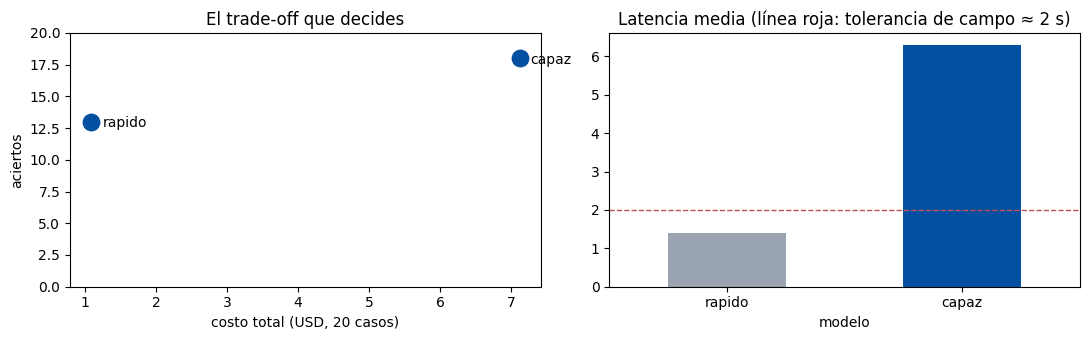

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for m, r in v["eval_20"].items():
    ax[0].scatter(r["costo_total"], r["aciertos"], s=140, color="#0350a1")
    ax[0].annotate(m, (r["costo_total"], r["aciertos"]), textcoords="offset points", xytext=(8, -4))
ax[0].set_xlabel("costo total (USD, 20 casos)"); ax[0].set_ylabel("aciertos"); ax[0].set_ylim(0, 20)
ax[0].set_title("El trade-off que decides")
df_c["latencia_media_s"].plot.bar(ax=ax[1], color=["#9aa5b1", "#0350a1"], rot=0)
ax[1].axhline(2.0, ls="--", color="#c0504d", lw=1)
ax[1].set_title("Latencia media (línea roja: tolerancia de campo ≈ 2 s)")
plt.tight_layout(); plt.show()

**Qué deberías ver:** a la izquierda, cada modelo como un punto costo-vs-aciertos (el trade-off completo en una mirada); a la derecha, la latencia de cada uno contra la línea roja de tolerancia de campo (~2 s). Si un modelo queda arriba de esa línea, no importa cuánto acierte: el preventista no va a esperar.

### Cómo leer esta evidencia

- **USD por acierto** suele decir más que el costo total: pagar más por modelo puede salir más barato por resultado. Verifícalo en tu tabla.
- **La latencia es un requisito, no una métrica de empate**: en campo, una respuesta de 6 segundos con el preventista esperando frente al tendero puede ser peor que una respuesta imperfecta en 1.4. En el lote nocturno, la latencia es irrelevante.
- **Los aciertos están precargados**: cambiar tu criterio no cambia esta tabla. Explica qué parte de tu criterio puede contrastarse con estas métricas y qué evidencia adicional necesitarías. No atribuyas a los agregados una comprobación que no permiten hacer.

In [12]:
# CELDA DE RUPTURA | El experimento contrafactual
print("Imagina que el criterio lo defines AHORA, con la tabla enfrente.")
print("¿Qué modelo 'ganaría' si eligieras el criterio que favorece al que ya te gustaba?")
print()
print("Ese movimiento tiene nombre (sesgo de confirmación) y antídoto (criterio previo).")
print("En tu organización lo verás seguido: la métrica elegida después de la demo. Ahora sabes qué preguntar:")
print("   «¿el criterio se definió antes o después de ver las salidas?»")

Imagina que el criterio lo defines AHORA, con la tabla enfrente.
¿Qué modelo 'ganaría' si eligieras el criterio que favorece al que ya te gustaba?

Ese movimiento tiene nombre (sesgo de confirmación) y antídoto (criterio previo).
En tu organización lo verás seguido: la métrica elegida después de la demo. Ahora sabes qué preguntar:
   «¿el criterio se definió antes o después de ver las salidas?»


## Sección D — Model Decision Card

### El concepto

Una **Model Decision Card** es el registro mínimo y auditable de una decisión de modelo: qué se decidió, con qué evidencia, qué riesgo se acepta y cómo se vigila. Es la pieza que convierte «elegimos el modelo X» en algo que un tercero puede revisar — y conecta directo con el plano de responsabilidad de la lección 1.4: toda decisión tiene un autor y una evidencia, o no es una decisión sino una preferencia.

**Ejemplo del nivel esperado** (otra tarea: clasificación de tickets):
> *Decisión:* modelo rápido. *Justificación:* clasificación con criterios visibles; el capaz acierta 2 casos más de 200 diarios pero cuesta 8x y la latencia no importa en lote; error barato y reversible (un ticket mal ruteado se reencola). *Riesgo residual:* deriva de vocabulario. *Mitigación:* muestreo semanal de 20 casos contra criterio.

```
  MODEL DECISION CARD
  +---------------------------------------------------+
  |  decisión        →  rapido | capaz                |
  |  justificación   →  ≥ 2 evidencias con números    |
  |  riesgo residual →  qué puede salir mal aun así   |
  |  mitigación      →  cómo lo vigilas y cada cuándo |
  +---------------------------------------------------+
   quién decidió + con qué evidencia + qué vigila
   = responsabilidad con nombre (lección 1.4)
```

In [13]:
# DECISIÓN | Una card por tarea. Usa la evidencia de las secciones A, B y C.
card_campo = {
    "tarea": "consulta de campo (síncrona, alto volumen)",
    "decision": "rapido",
    "justificacion": """Decisión provisional: ningún modelo cumple el criterio previo. El rápido es el único que respeta el requisito duro de latencia (1.4 s contra 6.3 s del capaz, tolerancia 2.0 s), pero sus 13/20 aciertos (65 %) quedan debajo del umbral de 15/20. El capaz (18/20 aciertos) queda descartado por latencia, y además cuesta 0.396 USD por acierto contra 0.084 USD del rápido (4.7 veces más). En campo el humano está presente y el error es tolerable; por eso se adopta el rápido como asistente sugerido, no como respuesta autónoma, sin reescribir el criterio.""",
    "riesgo_residual": """Con 65 % de acierto, de 1000 consultas diarias cerca de 350 podrían traer una cifra equivocada (precio, inventario o promoción). Si el preventista confía sin verificar, el error llega al pedido y al tendero. Los agregados tampoco permiten saber si los errores son cifras inventadas u omisiones.""",
    "mitigacion": """Respuesta siempre con la cifra y su fuente (SKU y renglón del catálogo) para que el preventista la confirme; contexto acotado a los renglones pertinentes con la evidencia al inicio o al final. Muestreo semanal de 20 casos calificados contra el criterio; si en 4 semanas no se alcanzan 15/20 aciertos, revisar el contexto o evaluar un modelo intermedio que cumpla 2.0 s. Monitoreo diario de latencia (alerta si la media pasa de 2.0 s).""",
}
card_nocturno = {
    "tarea": "resumen nocturno de incidentes (lote, alta exigencia)",
    "decision": "capaz",
    "justificacion": """Cumple el criterio previo: 18/20 aciertos (90 %) contra 13/20 del rápido, es decir 2 errores por cada 20 contra 7, y un error aquí llega al comité sin filtro. Su latencia de 6.3 s es irrelevante en lote. Es una sola corrida por noche: el reporte de 449 tokens cuesta 0.00056 USD de entrada con el capaz, y aun con el costo simulado completo (7.12 USD por 20 casos, 0.356 USD por caso) el gasto diario es marginal frente al costo de un error.""",
    "riesgo_residual": """La evaluación de 20 casos es de la tarea de campo, no de síntesis de incidentes: el 90 % no está medido para el resumen nocturno. Sigue habiendo 1 de cada 10 resúmenes con un error que el gerente podría llevar al comité.""",
    "mitigacion": """Antes de producción, evaluar 20 resúmenes reales de incidentes contra un criterio escrito antes (incidente citado con tienda y SKU correctos, sin incidentes inventados). Después, el gerente revisa 2 resúmenes por semana contra el reporte fuente y se registra cada error; si baja de 18/20 en el muestreo mensual, se reabre la decisión.""",
}

In [14]:
def evidencias_numericas(texto):
    """Detecta citas con número y unidad cercanos; no acredita su veracidad."""
    if not isinstance(texto, str):
        return set()
    numero = r'\d+(?:[.,]\d+)?(?:\s*/\s*\d+)?'
    unidades = {
        'tokens': r'tokens?',
        'costo': r'USD|dólares|\$',
        'aciertos': r'aciertos?',
        'latencia': r'segundos?|s\b|ms\b',
    }
    citas = set()
    for categoria, unidad in unidades.items():
        patron = rf'(?P<antes>{numero})\s*(?:{unidad})(?!\w)|(?:{unidad})\s*[:=]?\s*(?P<despues>{numero})'
        for coincidencia in re.finditer(patron, texto, re.I):
            valor = coincidencia.group('antes') or coincidencia.group('despues')
            citas.add((categoria, re.sub(r'\s+', '', valor).replace(',', '.')))
    return citas

def validar_card(card: dict) -> list:
    """Comprueba completitud formal, no calidad académica ni exactitud de las citas."""
    if not isinstance(card, dict):
        return ['La card debe ser un diccionario.']
    pendientes = []
    if card.get('decision') not in ('rapido', 'capaz'):
        pendientes.append("decision debe ser 'rapido' o 'capaz'")
    for campo in ('justificacion', 'riesgo_residual', 'mitigacion'):
        if not texto_completo(card.get(campo)):
            pendientes.append(f'{campo} está vacío, tiene tipo incorrecto o conserva un marcador')
    if len(evidencias_numericas(card.get('justificacion'))) < 2:
        pendientes.append('Cita al menos dos evidencias numéricas, sin repetir la misma cifra y unidad como si fueran dos evidencias. Escribe número y unidad juntos (p. ej., 13/20 aciertos y 1.4 s). Si el control no reconoce tu redacción, revisa ese formato; la evaluación sigue siendo docente.')
    return pendientes

for card in (card_campo, card_nocturno):
    p = validar_card(card)
    print(f"— {card.get('tarea', '(tarea sin nombre)')}")
    if p:
        for x in p: print(f'   {x}')
    else:
        print('   Completitud formal: OK. Contrasta tú las cifras; el profesor revisa su pertinencia y el razonamiento.')

— consulta de campo (síncrona, alto volumen)
   Completitud formal: OK. Contrasta tú las cifras; el profesor revisa su pertinencia y el razonamiento.
— resumen nocturno de incidentes (lote, alta exigencia)
   Completitud formal: OK. Contrasta tú las cifras; el profesor revisa su pertinencia y el razonamiento.


In [15]:
# Declaración de uso de IA (requisito del curso: qué herramientas usaste, para qué, y qué verificaste tú)
DECLARACION_IA = """  """
print("Declaración registrada" if texto_completo(DECLARACION_IA) else "Falta tu declaración de uso de IA.")

Falta tu declaración de uso de IA.


# Resumen para tu PDF de resultados

Ejecuta esta celda al final. Reúne los resultados y señala campos que todavía debes completar. Integra en un solo PDF tus resultados, las interpretaciones de A y B, el criterio y sus límites, ambas cards, conclusiones y declaración de uso de IA (o indica que no la utilizaste). La revisión es docente, conforme a la rúbrica de Canvas: 3 puntos de resultados y 2 de interpretación. No hay quiz de captura ni entrega adicional del notebook. Un control sin pendientes no acredita por sí solo la calidad de tu trabajo.

In [16]:
pendientes = []
try:
    comprobar_criterio()
except ValueError as error:
    pendientes.append(str(error))
if not isinstance(TEXTO_QUE_NO_ENTRA_COMPLETO, str) or TEXTO_QUE_NO_ENTRA_COMPLETO not in v["texto_tokens"]:
    pendientes.append("nombre válido de texto (A)")
if not texto_completo(POR_QUE): pendientes.append("justificación POR_QUE (A)")
pendientes += [f"card campo: {x}" for x in validar_card(card_campo)]
pendientes += [f"card nocturno: {x}" for x in validar_card(card_nocturno)]
if not texto_completo(DECLARACION_IA): pendientes.append("declaración de IA (D)")

print("=" * 56)
print(f"RESUMEN DE RESULTADOS — {CODIGO_LAB}")
print("=" * 56)
print(f"1. Tokens del catálogo:            {v['texto_tokens']['catalogo']}")
print(f"2. Razón español/inglés:           {v['ratio_es_en']}")
print(f"3. Score con evidencia en medio:   {v['pos_score']['medio']}")
print(f"4. Aciertos del modelo capaz:      {v['eval_20']['capaz']['aciertos']}/20")
print(f"5. Costo total del rápido:         ${v['eval_20']['rapido']['costo_total']}")
print(f"6. Tu decisión para campo:         {card_campo.get('decision') if isinstance(card_campo, dict) and card_campo.get('decision') in ('rapido','capaz') else '(pendiente)'}")
print("=" * 56)
if pendientes:
    print("ANTES DE PREPARAR EL PDF te falta:"); [print(f"   - {x}") for x in pendientes]
else:
    print("Sin pendientes en los controles formales. Revisa también tus interpretaciones y conclusiones, que este código no califica.")
    print("Entrega tu PDF de resultados en la tarea de Canvas; comprueba que sea legible y corresponda al conjunto común del laboratorio.")

RESUMEN DE RESULTADOS — LAB1-A
1. Tokens del catálogo:            1580
2. Razón español/inglés:           1.32
3. Score con evidencia en medio:   0.71
4. Aciertos del modelo capaz:      18/20
5. Costo total del rápido:         $1.09
6. Tu decisión para campo:         rapido
ANTES DE PREPARAR EL PDF te falta:
   - declaración de IA (D)


# Conclusiones y recomendación de negocio

* **Conclusión técnica:** para campo la evidencia decisiva fue la latencia (1.4 s contra 6.3 s frente a una tolerancia de 2.0 s), que descarta al capaz aunque acierte 18/20; para el resumen nocturno lo decisivo fue la diferencia de aciertos (18/20 contra 13/20), porque ahí la latencia no importa y el error no tiene filtro. Lo que sorprendió: ningún modelo cumple el criterio de campo, y aquí pagar más no sale más barato por resultado (0.396 contra 0.084 USD por acierto); además, solo reordenar el contexto vale un 19 % de desempeño sin pagar un token más.
* **Recomendación a la dirección:** usar el modelo rápido como asistente sugerido en campo (alrededor de 54.5 USD al día por 1000 consultas según el costo simulado de la evaluación), vigilando cada semana que suba a 15 de 20 aciertos, y el modelo capaz para el resumen nocturno (alrededor de 0.36 USD por corrida), validándolo antes con 20 resúmenes reales de incidentes.

---
**Qué sigue:** en el Skill Lab 2 dejarás de elegir el modelo y empezarás a auditar su comportamiento.